# Predicting High-Income Individuals from Demographic Data

## Hypothesis
Can demographic and employment-related attributes predict whether an individual earns more than $50K annually?

## Objective
To analyze census data from the UCI Adult dataset and build a classification model that predicts income level based on demographic, education, and work-related features.

## Method Used
Classification (Logistic Regression, Decision Tree, Random Forest, etc.)


## Dataset Selection

- **Dataset**: UCI Adult Income Dataset  
- **Source**: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/2/adult)  
- **Description**: This dataset contains demographic and employment-related information from the 1994 U.S. Census database. The goal is to build a classification model that predicts whether an individual earns more than $50K annually based on attributes like age, education, occupation, and hours worked.


In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [10]:
# Extract column names from adult.names file
with open("adult-data/adult.names", "r") as f:
    lines = f.readlines()

column_names = [
    line.split(":")[0].strip()
    for line in lines
    if ":" in line and not line.startswith("|")
]
column_names.append("income")

# Load dataset
df = pd.read_csv(
    "adult-data/adult.data",
    header=None,
    names=column_names,
    na_values="?",
    skipinitialspace=True
)

# Preview the dataset
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Initial Dataset Overview

### 1. Feature Description

| **Feature**        | **Type**      | **Description**                                                             |
|--------------------|---------------|------------------------------------------------------------------------------|
| `age`              | Numerical     | Age of the individual                                                       |
| `workclass`        | Categorical   | Type of employment (e.g., Private, Self-emp, Government)                    |
| `fnlwgt`           | Numerical     | Final weight (represents how many people the entry represents)             |
| `education`        | Categorical   | Highest level of education (e.g., Bachelors, HS-grad)                       |
| `education-num`    | Numerical     | Number of years of education (numeric version of `education`)              |
| `marital-status`   | Categorical   | Marital status (e.g., Married, Never-married)                               |
| `occupation`       | Categorical   | Type of occupation (e.g., Exec-managerial, Handlers-cleaners)              |
| `relationship`     | Categorical   | Household relationship (e.g., Husband, Not-in-family)                       |
| `race`             | Categorical   | Race (e.g., White, Black, Asian-Pac-Islander)                               |
| `sex`              | Categorical   | Gender (Male or Female)                                                     |
| `capital-gain`     | Numerical     | Income from capital gains (e.g., profit from selling stocks or property)   |
| `capital-loss`     | Numerical     | Capital loss (e.g., money lost in investments)                              |
| `hours-per-week`   | Numerical     | Number of hours worked per week                                             |
| `native-country`   | Categorical   | Country of origin (e.g., United-States, Mexico, India)                      |
| `income`           | Binary        | Target variable: Whether income is >50K or <=50K                            |

---

### 🏷️ Target Variable
- **`income`**: Classification target — values are:
  - `<=50K`: Low income
  - `>50K`: High income

---

### 🗂️ Feature Types Summary
- **Numerical Features**:  
  `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`  
- **Categorical Features**:  
  `workclass`, `education`, `marital-status`, `occupation`, `relationship`,  
  `race`, `sex`, `native-country`


### 2. Dataset Structure


In [12]:
# Display shape of the dataset
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")



Total Rows: 32561
Total Columns: 15


### 3. Missing Values and Duplicates


In [13]:
# Check missing values
df.isna().sum()


age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

### 4. Statistical Summary

This section provides a statistical overview of the numerical features, including count, mean, standard deviation, min, and max values. It helps understand feature distributions and detect potential anomalies such as outliers.


In [14]:
# Summary statistics for numerical columns
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### 5. Interpretation of Statistical Summary

Below are key observations from the numerical feature summary:

- **Age**: Ranges from 17 to 90 years, with a median of 37. Most individuals are between 28 and 48.
- **fnlwgt**: Ranges widely (12K to 1.48M) — used for sampling weight in census.
- **Education-num**: Maps to years of education (1–16). Median is 10, most common range is 9–12.
- **Capital-gain** and **Capital-loss**: Many zero values (25%, 50%, and 75% quantiles are all 0), but a few very high outliers — suggesting skewed distribution.
- **Hours-per-week**: Mostly between 40 and 45 hours, with a minimum of 1 and max of 99. Median is exactly 40, indicating a large portion work full-time.

This summary reveals that:
- Many features are skewed or imbalanced (especially capital-gain/loss).
- Age and hours-per-week show more typical bell-shaped distributions.
- Feature scaling and outlier detection will be important in preprocessing.


### 6. Basic Visualizations

Visualizing feature distributions helps us better understand data spread, detect outliers, and observe potential class separations (especially with respect to the income variable).


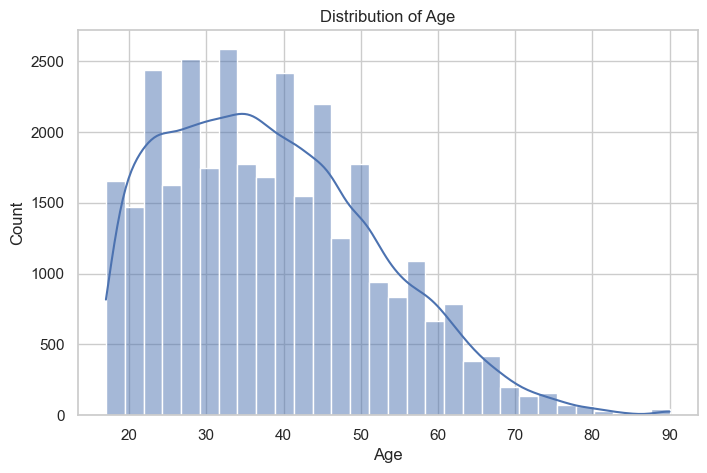

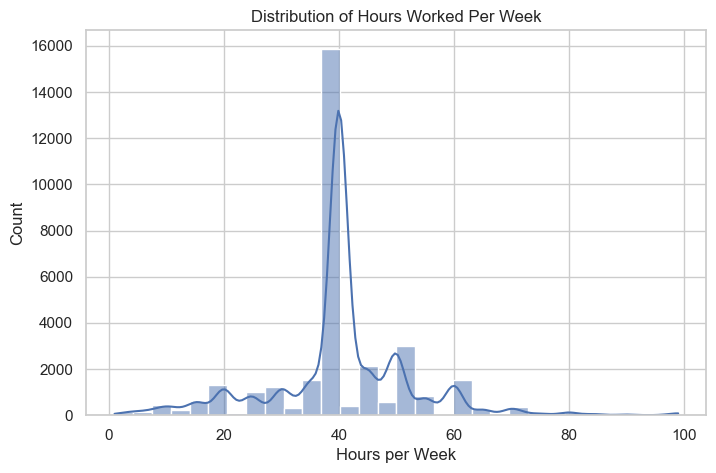

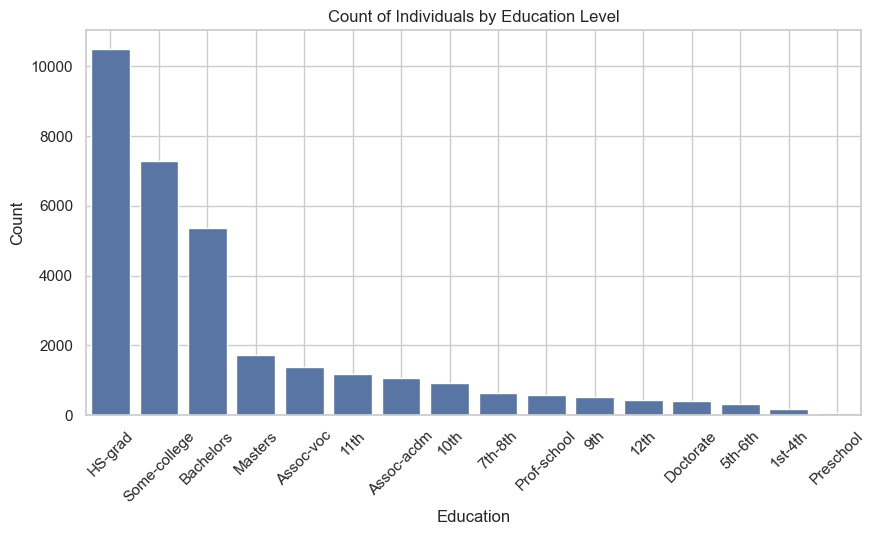

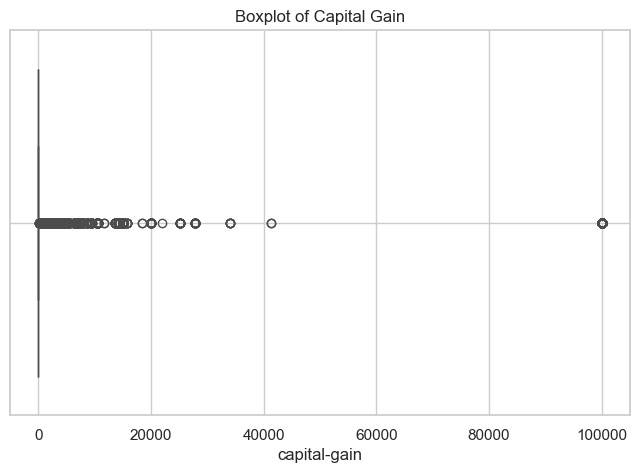

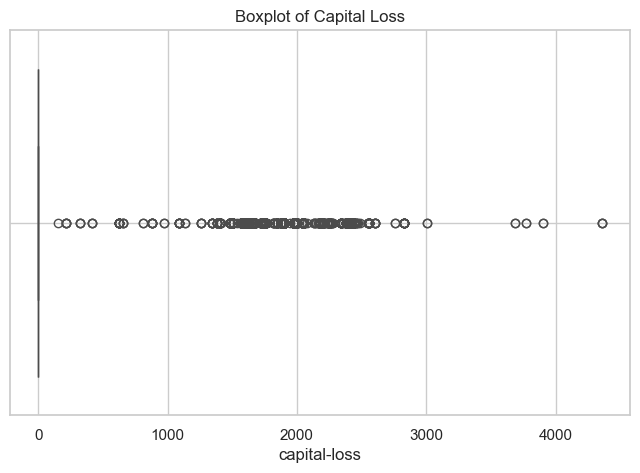

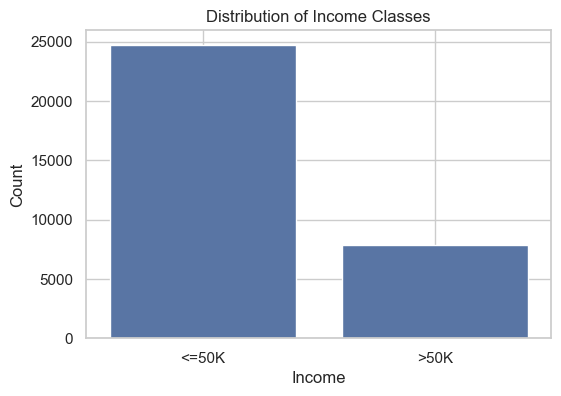

In [28]:
# Age distribution with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True, bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Distribution of hours worked per week
plt.figure(figsize=(8, 5))
sns.histplot(df['hours-per-week'], kde=True, bins=30)
plt.title("Distribution of Hours Worked Per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Barplot of education levels
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education', order=df['education'].value_counts().index)
plt.title("Count of Individuals by Education Level")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Education")
plt.grid(True)
plt.show()

# Boxplot for capital gain (to show outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='capital-gain')
plt.title("Boxplot of Capital Gain")
plt.grid(True)
plt.show()

# Boxplot for capital loss (to show outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='capital-loss')
plt.title("Boxplot of Capital Loss")
plt.grid(True)
plt.show()

# Distribution of target variable (income)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='income')
plt.title("Distribution of Income Classes")
plt.xlabel("Income")
plt.ylabel("Count")
plt.grid(True)
plt.show()


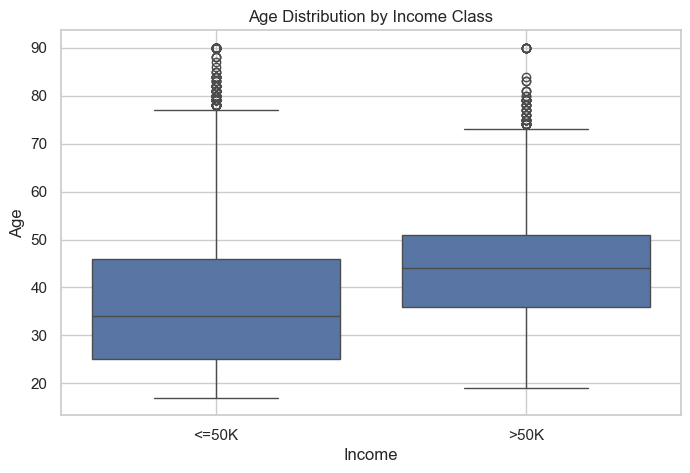

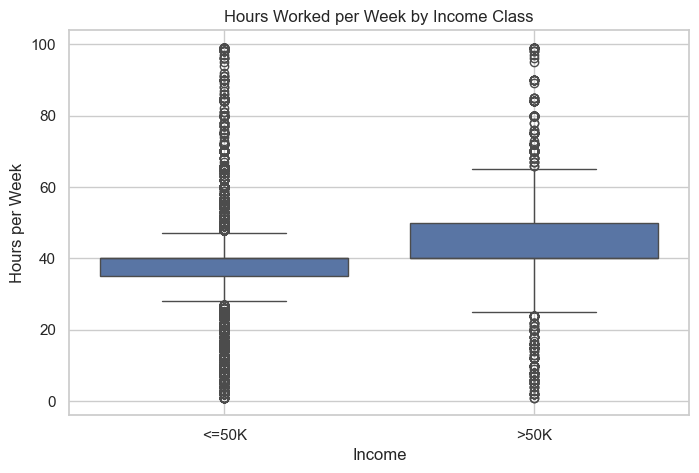

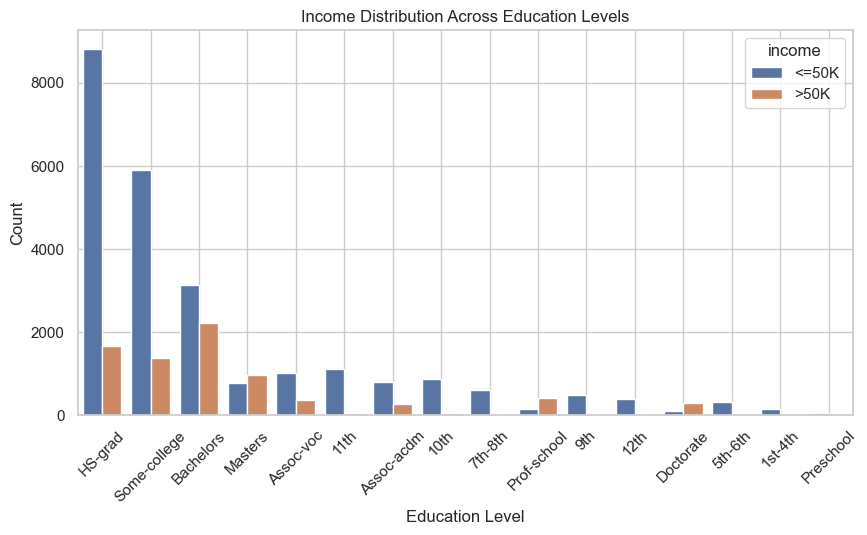

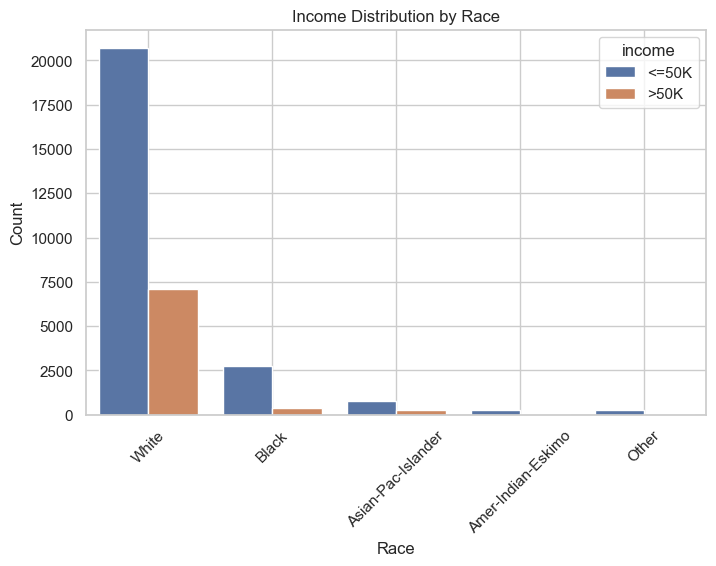

In [29]:
# Age distribution by income class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='age')
plt.title("Age Distribution by Income Class")
plt.xlabel("Income")
plt.ylabel("Age")
plt.grid(True)
plt.show()

# Hours worked per week by income class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title("Hours Worked per Week by Income Class")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.grid(True)
plt.show()

# Education level by income class
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education', hue='income', order=df['education'].value_counts().index)
plt.title("Income Distribution Across Education Levels")
plt.xticks(rotation=45)
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Race and income comparison
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='race', hue='income')
plt.title("Income Distribution by Race")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Race")
plt.grid(True)
plt.show()


## Feature Preprocessing Considerations

Before sending the data into machine learning models, the following features require special attention:

| **Feature**        | **Preprocessing Need**                                                                 |
|--------------------|----------------------------------------------------------------------------------------|
| `fnlwgt`           | ✔️ Retain and treat as a continuous numeric feature. Scale with others.               |
| `capital-gain`     | ⚠️ Skewed distribution with outliers. Consider log transformation or robust scaling.  |
| `capital-loss`     | ⚠️ Same as above — most values are 0, with a few very large ones.                     |
| `education-num`    | ✔️ Already numeric and clean. Scale directly.                                          |
| `hours-per-week`   | ✔️ Normal distribution, just scale.                                                    |
| `age`              | ✔️ Continuous, suitable for direct scaling.                                            |
| `workclass`        | ⚠️ Contains missing values. Handle before encoding.                                    |
| `occupation`       | ⚠️ Contains missing values. Handle before encoding.                                    |
| `native-country`   | ⚠️ Contains missing values. Handle before encoding.                                    |
| Categorical features (e.g., `education`, `marital-status`, `relationship`, `race`, `sex`) | ✔️ Clean but require encoding. One-hot encoding is suitable. |

### 📝 Summary

- Missing values must be handled before encoding or scaling.
- Skewed features (capital-gain/loss) require attention to avoid model distortion.
- All numerical features should be scaled.
